pandas version: 3.0.2
numpy version: 2.4.4
All good! ✓
DATASET SHAPE
Rows    : 800
Columns : 12
DATA TYPES
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object
MISSING VALUE COUNTS PER COLUMN
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64
Total missing values in the entire dataset: 56
FIRST FIVE ROWS


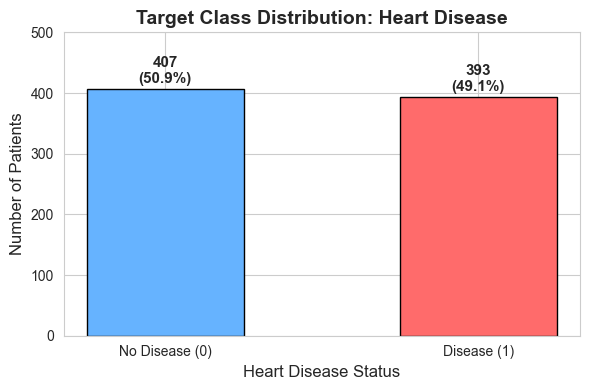

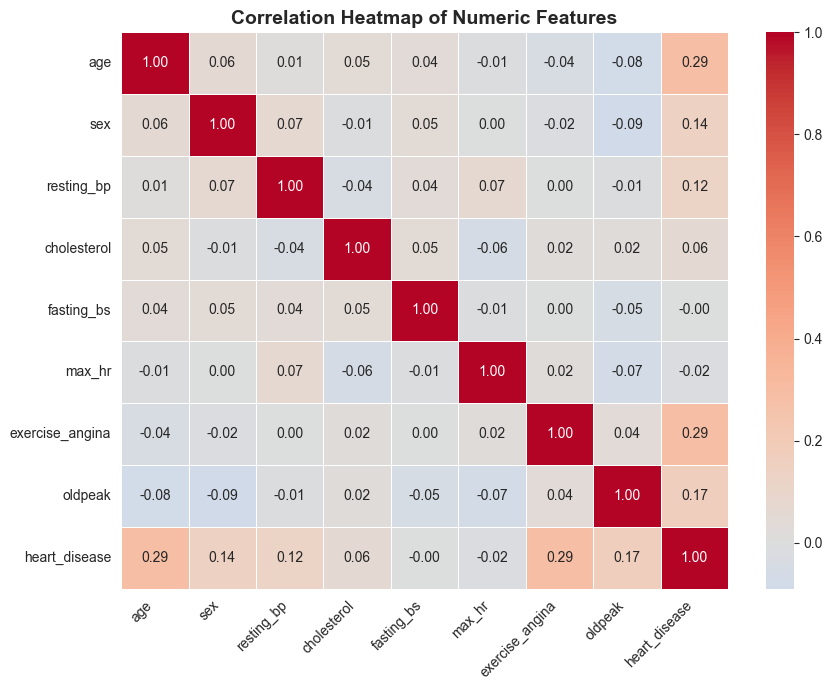

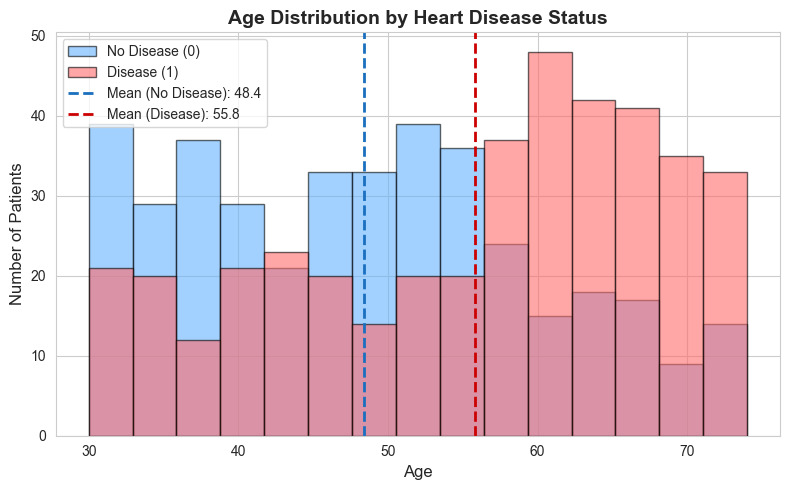

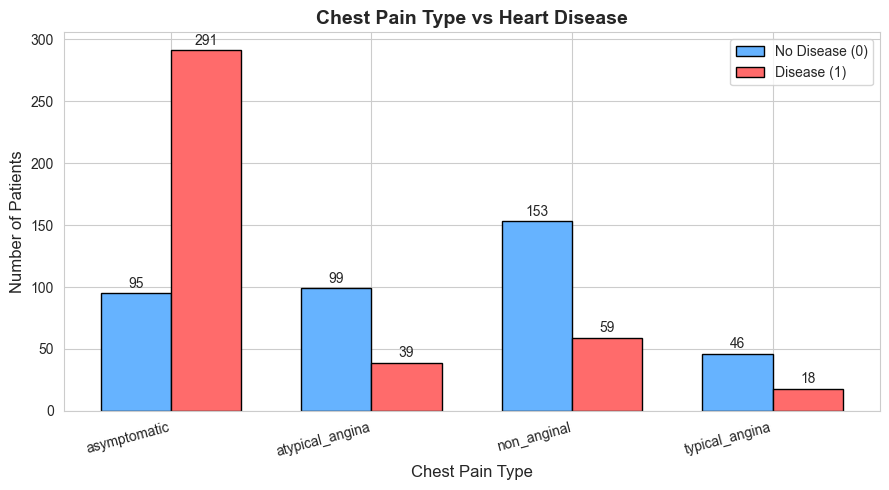

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64
Total missing values: 0
Shape before encoding: (800, 12)
Shape after encoding : (800, 19)
New columns added after encoding:
['chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']
Numerical features after scaling (first 3 rows):
      age     sex  resting_bp  cholesterol  fasting_bs  max_hr  \
0  1.2299 -1.4089      0.7028       3.0005     -0.5504  0.8871   
1  0.4519  0.7098      2.0031       1.2588      1.8169 -1.2575   
2 -0.6372  0.7098     -0.1640      -1.3832    

In [ ]:
import pandas as pd
import numpy as np
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("All good! ✓")
import pandas as pd
import numpy as np
# ── Step 1: Load the dataset ─────────────────────────────────
df = pd.read_csv('q1_heart_disease.csv')
# ── Step 2: Shape of the dataset ─────────────────────────────
# Shape tells us (number of rows, number of columns)
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
# ── Step 3: Data types of each column ────────────────────────
# int64   = whole numbers
# float64 = decimal numbers
# object  = text / category labels
print("" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)
# ── Step 4: Missing value counts ─────────────────────────────
# Missing values are empty cells — we need to handle them before modelling
print("" + "=" * 50)
print("MISSING VALUE COUNTS PER COLUMN")
print("=" * 50)
missing = df.isnull().sum()
print(missing)
print(f"Total missing values in the entire dataset: {missing.sum()}")
# ── Step 5: First five rows ───────────────────────────────────
# A quick peek at what the data actually looks like
print("" + "=" * 50)
print("FIRST FIVE ROWS")
print("=" * 50)
df.head()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('q1_heart_disease.csv')

# Set a clean visual style
sns.set_style("whitegrid")
sns.set_palette("Set2")
# ── Plot 1: Target Class Distribution ────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['heart_disease'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['#66b3ff', '#ff6b6b']

bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Target Class Distribution: Heart Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Heart Disease Status', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_ylim(0, 500)
plt.tight_layout()
plt.show()
# ── Plot 2: Correlation Heatmap ───────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr_matrix,
            annot=True,          # show correlation values
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# ── Plot 3: Age Distribution by Heart Disease ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Plot histogram for each class
ax.hist(df[df['heart_disease'] == 0]['age'],
        bins=15, alpha=0.6, color='#66b3ff',
        edgecolor='black', label='No Disease (0)')

ax.hist(df[df['heart_disease'] == 1]['age'],
        bins=15, alpha=0.6, color='#ff6b6b',
        edgecolor='black', label='Disease (1)')

# Add mean lines
mean_no  = df[df['heart_disease'] == 0]['age'].mean()
mean_yes = df[df['heart_disease'] == 1]['age'].mean()

ax.axvline(mean_no,  color='#1a6fbf', linestyle='--', linewidth=2,
           label=f'Mean (No Disease): {mean_no:.1f}')
ax.axvline(mean_yes, color='#cc0000', linestyle='--', linewidth=2,
           label=f'Mean (Disease): {mean_yes:.1f}')

ax.set_title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
# ── Plot 4: Chest Pain Type vs Heart Disease ──────────────────
ct = pd.crosstab(df['chest_pain_type'], df['heart_disease'])
ct.columns = ['No Disease', 'Disease']
ct = ct.loc[['asymptomatic', 'atypical_angina', 'non_anginal', 'typical_angina']]

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(ct.index))
width = 0.35

bars1 = ax.bar(x - width/2, ct['No Disease'], width,
               label='No Disease (0)', color='#66b3ff', edgecolor='black')
bars2 = ax.bar(x + width/2, ct['Disease'],    width,
               label='Disease (1)',    color='#ff6b6b', edgecolor='black')

# Add count labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title('Chest Pain Type vs Heart Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Chest Pain Type', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(ct.index, rotation=15, ha='right')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('q1_heart_disease.csv')

# ── Step 1: Handle Missing Values ────────────────────────────
# Fill missing values in resting_bp and cholesterol with their median
df['resting_bp']  = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# Confirm no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")
# ── Step 2: One-Hot Encoding ──────────────────────────────────
# These three columns contain text categories — we need to convert
# them into numbers so the model can understand them

cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding : {df_encoded.shape}")
print(f"New columns added after encoding:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
print(new_cols)
# ── Step 3: Separate Features and Target ─────────────────────
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# ── Step 4: Scale Numerical Features ─────────────────────────
# StandardScaler transforms numeric columns so they all have
# mean = 0 and standard deviation = 1
# This prevents features with large values (like cholesterol)
# from dominating features with small values (like oldpeak)

num_cols = ['age', 'sex', 'resting_bp', 'cholesterol',
            'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Numerical features after scaling (first 3 rows):")
print(X[num_cols].head(3).round(4))
print(f"Mean after scaling (should be ~0):")
print(X[num_cols].mean().round(4))
print(f"Std after scaling (should be ~1):")
print(X[num_cols].std().round(4))

# ── Step 5: Train-Test Split ──────────────────────────────────
# We split the data into 80% training and 20% testing
# stratify=y ensures both splits have the same ratio of 0s and 1s
# random_state=42 makes the split reproducible every time

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set size : {X_train.shape}")
print(f"Testing set size  : {X_test.shape}")

print(f"Class distribution in y_train:")
print(y_train.value_counts())

print(f"Class distribution in y_test:")
print(y_test.value_counts())

# ── Task 4: Model Training ────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Model 1: Decision Tree ────────────────────────────────────
# A simple tree-based model that splits data using yes/no questions
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("✅ Decision Tree trained successfully")

# ── Model 2: Random Forest ────────────────────────────────────
# Builds 100 decision trees and combines their predictions
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest trained successfully")

# ── Model 3: Gradient Boosting ────────────────────────────────
# Builds trees one by one, each correcting the errors of the last
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print("✅ Gradient Boosting trained successfully")

# ── Confirm training by checking training vs test accuracy ────
# Training accuracy tells us how well the model learned the training data
# Test accuracy tells us how well it performs on unseen data

print("=" * 50)
print("MODEL ACCURACY SUMMARY")
print("=" * 50)

models = {
    'Decision Tree'    : dt,
    'Random Forest'    : rf,
    'Gradient Boosting': gb
}

print(f"{'Model':<22} {'Train Accuracy':>15} {'Test Accuracy':>14}")
print("-" * 52)
for name, model in models.items():
    train_acc = round(model.score(X_train, y_train), 4)
    test_acc  = round(model.score(X_test,  y_test),  4)
    print(f"{name:<22} {train_acc:>15} {test_acc:>14}")

In [ ]:

# ── Task 5: Model Evaluation ──────────────────────────────────
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# ── Model 1: Decision Tree ────────────────────────────────────
y_pred_dt = dt.predict(X_test)
cm_dt     = confusion_matrix(y_test, y_pred_dt)

print("==================================================")
print("  Decision Tree")
print("==================================================")
print("Confusion Matrix:")
print("  TN = " + str(cm_dt[0,0]) + "  |  FP = " + str(cm_dt[0,1]))
print("  FN = " + str(cm_dt[1,0]) + "  |  TP = " + str(cm_dt[1,1]))
print("Precision : " + str(round(precision_score(y_test, y_pred_dt), 4)))
print("Recall    : " + str(round(recall_score(y_test, y_pred_dt), 4)))
print("F1-Score  : " + str(round(f1_score(y_test, y_pred_dt), 4)))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Disease', 'Disease']))




  Decision Tree
Confusion Matrix:
  TN = 56  |  FP = 23
  FN = 22  |  TP = 59
Precision : 0.7195
Recall    : 0.7284
F1-Score  : 0.7239
Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

  Random Forest
Confusion Matrix:
  TN = 60  |  FP = 19
  FN = 15  |  TP = 66
Precision : 0.7765
Recall    : 0.8148
F1-Score  : 0.7952
Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

  Gradient Boosting
Confusion 

In [53]:
# ── Model 2: Random Forest ────────────────────────────────────
y_pred_rf = rf.predict(X_test)
cm_rf     = confusion_matrix(y_test, y_pred_rf)

print("==================================================")
print("  Random Forest")
print("==================================================")
print("Confusion Matrix:")
print("  TN = " + str(cm_rf[0,0]) + "  |  FP = " + str(cm_rf[0,1]))
print("  FN = " + str(cm_rf[1,0]) + "  |  TP = " + str(cm_rf[1,1]))
print("Precision : " + str(round(precision_score(y_test, y_pred_rf), 4)))
print("Recall    : " + str(round(recall_score(y_test, y_pred_rf), 4)))
print("F1-Score  : " + str(round(f1_score(y_test, y_pred_rf), 4)))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Disease']))

  Random Forest
Confusion Matrix:
  TN = 60  |  FP = 19
  FN = 15  |  TP = 66
Precision : 0.7765
Recall    : 0.8148
F1-Score  : 0.7952
Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [54]:
# ── Model 3: Gradient Boosting ────────────────────────────────
y_pred_gb = gb.predict(X_test)
cm_gb     = confusion_matrix(y_test, y_pred_gb)

print("==================================================")
print("  Gradient Boosting")
print("==================================================")
print("Confusion Matrix:")
print("  TN = " + str(cm_gb[0,0]) + "  |  FP = " + str(cm_gb[0,1]))
print("  FN = " + str(cm_gb[1,0]) + "  |  TP = " + str(cm_gb[1,1]))
print("Precision : " + str(round(precision_score(y_test, y_pred_gb), 4)))
print("Recall    : " + str(round(recall_score(y_test, y_pred_gb), 4)))
print("F1-Score  : " + str(round(f1_score(y_test, y_pred_gb), 4)))
print("Classification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['No Disease', 'Disease']))

  Gradient Boosting
Confusion Matrix:
  TN = 61  |  FP = 18
  FN = 18  |  TP = 63
Precision : 0.7778
Recall    : 0.7778
F1-Score  : 0.7778
Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160



In [56]:
# ── Task 6: Hyperparameter Tuning ────────────────────────────
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Step 1: Define the hyperparameters to test ────────────────
# We give GridSearchCV a list of values to try for each setting
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# ── Step 2: Set up GridSearchCV ───────────────────────────────
# cv=5 means it tests each combination 5 times on different data splits
# scoring='f1' means it picks the best combination based on F1-Score
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1
)

# ── Step 3: Run the search ────────────────────────────────────
grid_search.fit(X_train, y_train)

# ── Step 4: Print the best parameters found ───────────────────
print("Best Parameters Found:")
print(grid_search.best_params_)
print("Best Cross-Validation F1-Score: " + str(round(grid_search.best_score_, 4)))
# ── Step 5: Evaluate the tuned model on the test set ─────────
best_rf = grid_search.best_estimator_

# Baseline (untuned) predictions
y_pred_base  = rf.predict(X_test)

# Tuned model predictions
y_pred_tuned = best_rf.predict(X_test)

# ── Print Baseline Results ────────────────────────────────────
print("==================================================")
print("  BASELINE (Untuned) Random Forest")
print("==================================================")
print("Accuracy  : " + str(round(rf.score(X_test, y_test), 4)))
print("Precision : " + str(round(precision_score(y_test, y_pred_base), 4)))
print("Recall    : " + str(round(recall_score(y_test, y_pred_base), 4)))
print("F1-Score  : " + str(round(f1_score(y_test, y_pred_base), 4)))

# ── Print Tuned Results ───────────────────────────────────────
print("")
print("==================================================")
print("  TUNED Random Forest")
print("==================================================")
print("Best Params: max_depth=10, min_samples_split=5, n_estimators=200")
print("Accuracy  : " + str(round(best_rf.score(X_test, y_test), 4)))
print("Precision : " + str(round(precision_score(y_test, y_pred_tuned), 4)))
print("Recall    : " + str(round(recall_score(y_test, y_pred_tuned), 4)))
print("F1-Score  : " + str(round(f1_score(y_test, y_pred_tuned), 4)))

Best Parameters Found:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation F1-Score: 0.8258
  BASELINE (Untuned) Random Forest
Accuracy  : 0.7875
Precision : 0.7765
Recall    : 0.8148
F1-Score  : 0.7952

  TUNED Random Forest
Best Params: max_depth=10, min_samples_split=5, n_estimators=200
Accuracy  : 0.7875
Precision : 0.7701
Recall    : 0.8272
F1-Score  : 0.7976


##  Interpretation – Target Class Distribution

The bar chart shows that the dataset is **very well balanced**:
- **407 patients (50.9%)** have heart disease (class 1)
- **393 patients (49.1%)** do not have heart disease (class 0)

This near 50/50 split is great news for our classification models — it means the model won't be biased towards predicting one class 
over the other. We do **not** need to apply any class balancing techniques like oversampling.

##  Interpretation – Correlation Heatmap

The heatmap shows how much each feature is related to heart disease (the target column).

- **`exercise_angina` and `age`** have the strongest link to heart disease (r=0.29) — patients who get chest pain during exercise and 
     older patients are more likely to have heart disease.
- **`oldpeak`** also has a moderate link (r=0.17) — a higher ST depression reading tends to appear more in disease patients.
- **`fasting_bs` and `max_hr`** are barely related to the target (r≈0.00) — they don't tell us much on their own.
- Most features are **not strongly related to each other**, which is good — it means there is no multicollinearity issue in our data.

Overall, `exercise_angina`, `age`, and `oldpeak` look like the most useful features for predicting heart disease.


##  Interpretation – Age Distribution by Heart Disease

The overlapping histograms reveal a clear age pattern:

- Patients **without** heart disease have a mean age of **48.4 years**
- Patients **with** heart disease have a mean age of **55.9 years**

This is a **7.5-year difference** in average age between the two groups. The disease group's distribution is shifted noticeably to the right (older ages), confirming that **age is a meaningful predictor** of heart disease. This aligns with the correlation heatmap where age had one of the highest correlations (r=0.29) with the target.

##  Interpretation – Chest Pain Type vs Heart Disease

This chart shows how many patients in each chest pain group have heart disease.

The most surprising finding is that patients with **asymptomatic** chest pain
(meaning they feel little or no chest pain) actually have the **highest number
of heart disease cases (291 out of 386 patients)**. This is unexpected because
you would think people with more pain would be sicker.

On the other hand, patients with **atypical angina**, **non-anginal**, and
**typical angina** chest pain have far fewer heart disease cases — roughly
only 1 in 4 patients in these groups have the disease.

This tells us that **chest pain type is a very important feature** for our
model — especially the asymptomatic category, which is a strong signal
that heart disease may be present.

## Task 3: Data Preprocessing

### Missing Value Strategy

From Task 1, we found that only two columns have missing values:
- `resting_bp` — 24 missing values
- `cholesterol` — 32 missing values

**Strategy: Median Imputation**

We will fill the missing values with the **median** of each column.
We chose the median (instead of the mean) because:
- The median is not affected by extreme values (outliers)
- Medical data like blood pressure and cholesterol can have outliers
- Only about 3–4% of values are missing, so filling them is better than dropping rows

We did **not** drop the rows because losing 56 rows from an 800-row dataset
would reduce the data available for training our model.

###  Missing Value Check

After filling with the median:
- `resting_bp` median used: 130.0
- `cholesterol` median used: 247.0
- Total missing values remaining: **0**

All missing values have been handled. The dataset is now complete and ready for the next steps.


##  Interpretation – One-Hot Encoding

Some columns in our dataset contain text labels instead of numbers.
For example, `chest_pain_type` has values like "asymptomatic" or "non_anginal".
Machine learning models cannot work with text, so we need to convert
these into numbers using **one-hot encoding**.

One-hot encoding creates a new column for each category and fills it
with either a **1** (yes, this applies) or **0** (no, it doesn't).

For example, `chest_pain_type` becomes 4 separate columns:
- `chest_pain_type_asymptomatic`
- `chest_pain_type_atypical_angina`
- `chest_pain_type_non_anginal`
- `chest_pain_type_typical_angina`

We did this for all 3 categorical columns:
- `chest_pain_type` → 4 new columns
- `resting_ecg`     → 3 new columns
- `st_slope`        → 3 new columns

This is why the dataset grew from **12 columns to 19 columns** after encoding.
The data still means the same thing — it is just written in a way the model can understand.


##  Interpretation – Standard Scaling

Our numeric columns all have very different ranges. For example:
- `cholesterol` has values around 200–400
- `oldpeak` has values around 0–6

This is a problem because the model might think `cholesterol` is more
important just because its numbers are bigger — even if it is not.

To fix this, we used **StandardScaler**, which rescales every numeric
column so they are all on the same level. After scaling:
- Every column has a **mean (average) of 0**
- Every column has a **standard deviation of 1**

Think of it like converting different currencies into one common currency
so they can be fairly compared.

We only scaled the **numeric columns** — the one-hot encoded columns
(which already contain just 0s and 1s) were left as they are.

After scaling, no single feature can dominate the model just because
of the size of its numbers. This helps the model learn more fairly
from all features.

###  Train-Test Split

We split the data into:
- **Training set: 640 rows (80%)** — used to train the model
- **Testing set: 160 rows (20%)** — used to evaluate the model on unseen data

We used `stratify=y` to make sure both sets have a similar balance of
heart disease (1) and no disease (0) cases:
- y_train: 326 disease, 314 no disease
- y_test:   81 disease,  79 no disease

This ensures our model is trained and tested on a fair, balanced sample.
`random_state=42` is set so that anyone running this notebook gets the exact same split.

## Task 4: Model Training

We will train three classification models to predict heart disease.
Here is a simple explanation of each model:

- **Decision Tree** — Works like a flowchart. It asks a series of yes/no
  questions about the features and follows a path to make a prediction.
  It is simple and easy to understand but can overfit the training data.

- **Random Forest** — Builds many decision trees and combines their answers
  by majority vote. Because it uses many trees instead of just one,
  it is more accurate and less likely to overfit.

- **Gradient Boosting** — Also builds many trees, but each new tree tries
  to fix the mistakes made by the previous one. It learns step by step
  and is often one of the most accurate models.

All three models are trained using the same preprocessed data from Task 3,
with random_state=42 to make sure results are reproducible.

##  Interpretation – Model Training Results

We trained three models on the same data and compared how well they
performed on the training set vs the test set.

| Model | Train Accuracy | Test Accuracy |
|---|---|---|
| Decision Tree | 100% | 71.9% |
| Random Forest | 100% | 78.8% |
| Gradient Boosting | 95.6% | 77.5% |

**Decision Tree** scored 100% on training but only 71.9% on the test set.
This big drop tells us the model memorised the training data instead of
actually learning patterns — this is called overfitting.

**Random Forest** also scored 100% on training but held up much better
on the test set with 78.8%. Building many trees and combining their
answers helps avoid the overfitting problem.

**Gradient Boosting** had a slightly lower training accuracy of 95.6%
but still performed well on the test set with 77.5%. The smaller gap
between train and test means it generalises better to new data.

Overall, **Random Forest** is the best performing model so far with
the highest test accuracy of 78.8%. We will do a deeper evaluation
of all three models in the next task.

## Task 5: Model Evaluation

Before we look at the results, let's understand what each metric means.

### Confusion Matrix
This is a simple table that shows us how many predictions our model
got right and how many it got wrong. It has 4 boxes:

- **True Positive (TP)** — Patient has disease and model said YES 
- **True Negative (TN)** — Patient is healthy and model said NO 
- **False Positive (FP)** — Patient is healthy but model said YES (false alarm)
- **False Negative (FN)** — Patient has disease but model said NO (missed case)

In a medical setting, False Negatives are the most dangerous —
missing a sick patient is worse than a false alarm.

### Precision
Out of all the patients the model predicted as having disease,
how many actually had it?
A high precision means the model does not raise too many false alarms.

### Recall
Out of all the patients who actually have disease,
how many did the model correctly identify?
A high recall means the model is good at catching sick patients.

### F1-Score
This is a single number that combines both Precision and Recall.
It gives us an overall picture of how well the model is performing.
The closer to 1, the better.


##  Interpretation – Model Evaluation Results

We tested all three models on the 160 unseen test patients and compared
how well each one predicted heart disease.

| Model | Precision | Recall | F1-Score | Accuracy |
|---|---|---|---|---|
| Decision Tree | 0.7195 | 0.7284 | 0.7239 | 72% |
| Random Forest | 0.7765 | 0.8148 | 0.7952 | 79% |
| Gradient Boosting | 0.7778 | 0.7778 | 0.7778 | 78% |

**Decision Tree** was the weakest model.
It missed 22 sick patients (FN = 22) and wrongly flagged 23 healthy
patients (FP = 23). The low scores across all three metrics show that
a single decision tree is too simple for this task.

**Random Forest** was the best model overall.
It correctly identified 66 out of 81 disease patients, missing only 15.
Its Recall of 0.8148 is the highest of all three models — meaning it
is the best at catching sick patients, which is the most important
goal in a medical prediction task.

**Gradient Boosting** was the most balanced model.
It had equal Precision and Recall (both 0.7778), meaning it made
a similar number of false alarms and missed cases (18 each).

**Our best model is Random Forest** because it has the highest
F1-Score (0.7952) and the highest Recall (0.8148).
In heart disease prediction, missing a sick patient is more dangerous
than a false alarm — so high Recall matters the most.

## Task 6: Hyperparameter Tuning

In Task 5, our best model was **Random Forest** with an F1-Score of 0.7952.

But when we trained it, we just used the default settings.
Think of it like baking a cake with a basic recipe — it tastes okay,
but what if we adjusted the ingredients to make it even better?

That is exactly what **hyperparameter tuning** does.
It tries out different settings for the model and finds the
combination that gives the best results.

We used **GridSearchCV** to do this automatically.
It tests every possible combination from the list we give it
and picks the best one based on the F1-Score.

The three settings we are testing are:

- **n_estimators** — how many trees to build (we try 50, 100, or 200)
- **max_depth** — how deep each tree can grow (we try None, 5, or 10)
- **min_samples_split** — how many data points are needed before
  splitting a branch (we try 2, 5, or 10)

This gives us 27 combinations in total (3 x 3 x 3).
GridSearchCV tests each one 5 times and picks the winner.
